In [1]:
from diffusers.models import AutoencoderKLFlux2
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
import time

device = "cuda"

In [ ]:
#!/usr/bin/env python3
"""
Tiny AutoEncoder for Stable Diffusion
(DNN for encoding / decoding SD's latent space)
"""
import torch
import torch.nn as nn


def conv(n_in, n_out, **kwargs):
    return nn.Conv2d(n_in, n_out, 3, padding=1, **kwargs)


class Clamp(nn.Module):
    def forward(self, x):
        return torch.tanh(x / 3) * 3


class Block(nn.Module):
    def __init__(self, n_in, n_out, use_midblock_gn=False):
        super().__init__()
        self.conv = nn.Sequential(
            conv(n_in, n_out),
            nn.ReLU(),
            conv(n_out, n_out),
            nn.ReLU(),
            conv(n_out, n_out),
        )
        self.skip = (
            nn.Conv2d(n_in, n_out, 1, bias=False) if n_in != n_out else nn.Identity()
        )
        self.fuse = nn.ReLU()
        self.pool = None
        if use_midblock_gn:
            conv1x1, n_gn = (
                lambda n_in, n_out: nn.Conv2d(n_in, n_out, 1, bias=False),
                n_in * 4,
            )
            self.pool = nn.Sequential(
                conv1x1(n_in, n_gn),
                nn.GroupNorm(4, n_gn),
                nn.ReLU(inplace=True),
                conv1x1(n_gn, n_in),
            )

    def forward(self, x):
        if self.pool is not None:
            x = x + self.pool(x)
        return self.fuse(self.conv(x) + self.skip(x))


def Encoder(latent_channels=4, use_midblock_gn=False):
    mb_kw = dict(use_midblock_gn=use_midblock_gn)
    return nn.Sequential(
        conv(3, 64),
        Block(64, 64),
        conv(64, 64, stride=2, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        conv(64, 64, stride=2, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        conv(64, 64, stride=2, bias=False),
        Block(64, 64, **mb_kw),
        Block(64, 64, **mb_kw),
        Block(64, 64, **mb_kw),
        conv(64, latent_channels),
    )


def Decoder(latent_channels=4, use_midblock_gn=False):
    mb_kw = dict(use_midblock_gn=use_midblock_gn)
    return nn.Sequential(
        Clamp(),
        conv(latent_channels, 64),
        nn.ReLU(),
        Block(64, 64, **mb_kw),
        Block(64, 64, **mb_kw),
        Block(64, 64, **mb_kw),
        nn.Upsample(scale_factor=2),
        conv(64, 64, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        nn.Upsample(scale_factor=2),
        conv(64, 64, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        nn.Upsample(scale_factor=2),
        conv(64, 64, bias=False),
        Block(64, 64),
        conv(64, 3),
    )


def F32Encoder(latent_channels=32):
    """Encoder variant with 32x spatial downscaling instead of 8x."""
    return nn.Sequential(
        conv(3, 32, stride=2),
        nn.ReLU(inplace=True),
        conv(32, 64, stride=2),
        nn.ReLU(inplace=True),
        Block(64, 64),
        conv(64, 64, stride=2, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        conv(64, 64, stride=2, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        conv(64, 64, stride=2, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        conv(64, latent_channels),
    )


def F32Decoder(latent_channels=32):
    """Decoder variant with 32x spatial upscaling instead of 8x."""
    return nn.Sequential(
        Clamp(),
        conv(latent_channels, 256),
        nn.ReLU(),
        Block(256, 256),
        Block(256, 256),
        Block(256, 256),
        nn.Upsample(scale_factor=2),
        conv(256, 128, bias=False),
        Block(128, 128),
        Block(128, 128),
        Block(128, 128),
        nn.Upsample(scale_factor=2),
        conv(128, 64, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        nn.Upsample(scale_factor=2),
        conv(64, 64, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        nn.Upsample(scale_factor=2),
        conv(64, 64, bias=False),
        Block(64, 64),
        Block(64, 64),
        Block(64, 64),
        nn.Upsample(scale_factor=2),
        conv(64, 64, bias=False),
        Block(64, 64),
        conv(64, 3),
    )


class TAESD(nn.Module):
    latent_magnitude = 3
    latent_shift = 0.5

    def __init__(
        self,
        encoder_path="taesd_encoder.pth",
        decoder_path="taesd_decoder.pth",
        latent_channels=None,
        arch_variant=None,
    ):
        """Initialize pretrained TAESD on the given device from the given checkpoints."""
        super().__init__()
        if latent_channels is None:
            latent_channels, arch_variant = self.guess_latent_channels_and_arch(
                str(encoder_path)
            )
        # flux_2 required global pooling/norm for accurate distillation, enable conditionally
        self.encoder = Encoder(
            latent_channels, use_midblock_gn=(arch_variant in ["flux_2"])
        )
        self.decoder = Decoder(
            latent_channels, use_midblock_gn=(arch_variant in ["flux_2"])
        )
        # sana dcae requires 32x spatial downscaling, enable conditionally
        if arch_variant == "f32":
            self.encoder, self.decoder = (
                F32Encoder(latent_channels),
                F32Decoder(latent_channels),
            )
        if encoder_path is not None:
            self.encoder.load_state_dict(
                torch.load(encoder_path, map_location="cpu", weights_only=True)
            )
        if decoder_path is not None:
            self.decoder.load_state_dict(
                torch.load(decoder_path, map_location="cpu", weights_only=True)
            )

    def guess_latent_channels(self, encoder_path):
        """Guess latent channel count based on encoder filename"""
        return self.guess_latent_channels_and_arch(encoder_path)[0]

    def guess_latent_channels_and_arch(self, encoder_path):
        """Guess latent channel count and architecture variant based on encoder filename"""
        if "taef1" in encoder_path:
            return 16, None
        if "taef2" in encoder_path:
            return 32, "flux_2"
        if "taesd3" in encoder_path:
            return 16, None
        if "taesana" in encoder_path:
            return 32, "f32"  # f32c32
        return 4, None

    @staticmethod
    def scale_latents(x):
        """raw latents -> [0, 1]"""
        return x.div(2 * TAESD.latent_magnitude).add(TAESD.latent_shift).clamp(0, 1)

    @staticmethod
    def unscale_latents(x):
        """[0, 1] -> raw latents"""
        return x.sub(TAESD.latent_shift).mul(2 * TAESD.latent_magnitude)


@torch.no_grad()
def main():
    from PIL import Image
    import sys
    import torchvision.transforms.functional as TF

    dev = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
    print("Using device", dev)
    taesd = TAESD().to(dev)
    for im_path in sys.argv[1:]:
        im = TF.to_tensor(Image.open(im_path).convert("RGB")).unsqueeze(0).to(dev)

        # encode image, quantize, and save to file
        im_enc = taesd.scale_latents(taesd.encoder(im)).mul_(255).round_().byte()
        enc_path = im_path + ".encoded.png"
        TF.to_pil_image(im_enc[0]).save(enc_path)
        print(f"Encoded {im_path} to {enc_path}")

        # load the saved file, dequantize, and decode
        im_enc = taesd.unscale_latents(
            TF.to_tensor(Image.open(enc_path)).unsqueeze(0).to(dev)
        )
        im_dec = taesd.decoder(im_enc).clamp(0, 1)
        dec_path = im_path + ".decoded.png"
        print(f"Decoded {enc_path} to {dec_path}")
        TF.to_pil_image(im_dec[0]).save(dec_path)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

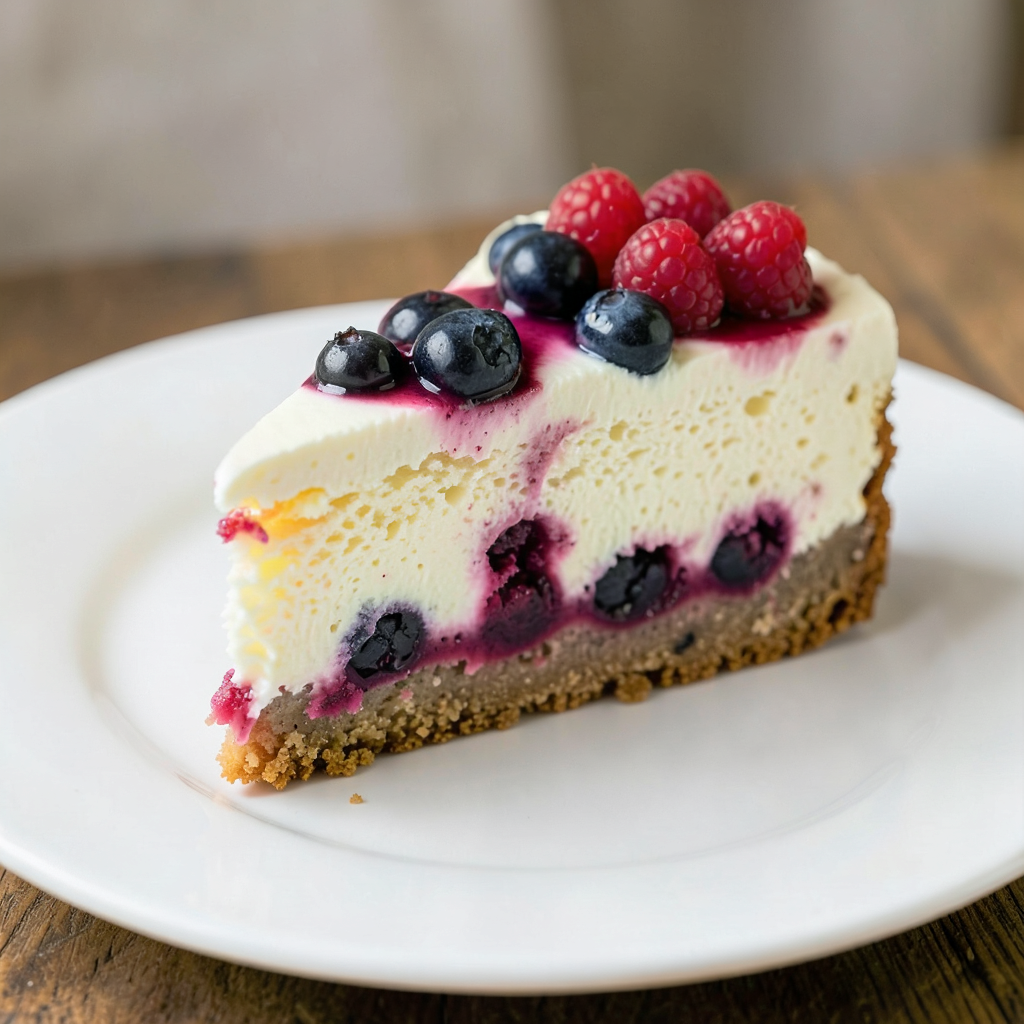

In [ ]:
# Construction
import torch
import safetensors.torch as stt
from diffusers.utils.accelerate_utils import apply_forward_hook


def convert_diffusers_sd_to_taesd(sd):
    out = {}
    for k, v in sd.items():
        encdec, _layers, index, *suffix = k.split(".")
        offset = 0
        if encdec == "decoder":
            offset = +1
        out[".".join([encdec, str(int(index) + offset), *suffix])] = v
    return out


class DotDict(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__


class DiffusersTAEF2Wrapper(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dtype = torch.bfloat16
        self.taesd = TAESD(
            encoder_path=None,
            decoder_path=None,
            latent_channels=32,
            arch_variant="flux_2",
        ).to(self.dtype)
        self.taesd.load_state_dict(
            convert_diffusers_sd_to_taesd(stt.load_file("../../taef2.safetensors"))
        )
        self.bn = torch.nn.BatchNorm2d(128, affine=False, eps=0.0)  # default bn
        self.config = DotDict(batch_norm_eps=self.bn.eps)

    @apply_forward_hook
    def encode(self, x):
        return DotDict(
            latent_dist=DotDict(
                sample=lambda: self.taesd.encoder(
                    x.to(self.dtype).mul(0.5).add_(0.5)
                ).to(x.dtype)
            )
        )

    @apply_forward_hook
    def decode(self, x, return_dict=True):
        x = (
            self.taesd.decoder(x.to(self.dtype))
            .mul(2)
            .sub_(1)
            .clamp_(-1, 1)
            .to(x.dtype)
        )
        return (dict(sample=x) if return_dict else x,)


taef2_diffusers = DiffusersTAEF2Wrapper().eval().requires_grad_(False)

# Usage
from diffusers import Flux2KleinPipeline

device = "cuda"
dtype = torch.bfloat16

pipe = Flux2KleinPipeline.from_pretrained(
    "black-forest-labs/FLUX.2-klein-4B", torch_dtype=dtype
)
pipe.vae = taef2_diffusers
pipe.enable_sequential_cpu_offload()  # pipe.enable_model_cpu_offload() # pipe = pipe.to(device)

prompt = "A slice of delicious New York-style berry cheesecake"
image = pipe(
    prompt=prompt,
    height=1024,
    width=1024,
    guidance_scale=1.0,
    num_inference_steps=4,
    generator=torch.Generator(device="cpu").manual_seed(0),
).images[0]
image.save("flux-klein.png")
image
